In [107]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

In [176]:
droc= data.copy()
def calc_roc(data ):
    pct= pd.Series(len(droc))
    for i in range (14, len(droc)-14):
        pct.loc[i] = (data['close'].iloc[i] - data['close'].iloc[i-14])/data['close'].iloc[i-14]
    pct.loc[0:14]=0
    return pct*100
        

In [178]:
data = pd.read_csv('btc (1).csv')
calc_roc(data)

0        0.000000
14       0.000000
15       1.478400
16      -0.882292
17      -0.948372
           ...   
37789   -0.355560
37790    0.105828
37791    0.160908
37792    0.914495
37793    0.900175
Length: 37781, dtype: float64

In [174]:
def calc_ema(data, window ):
    k = 2/ ( window +1) 
    ema=pd.Series(len(data))
    ema.loc[0]=1.00
    
    for i in range (1 , len(droc)):
        ema.loc[i]=(data['close'].loc[i]*k)/10000 +(ema.loc[i-1] * (1-k))
    return ema


    

def calc_nvi( data):
    nvi = pd.Series(len(droc))
    nvi.loc[0] = 1
    for i in range(1, len(droc)):
        if droc['volume'].iloc[i] < droc['volume'].iloc[i-1]:
            nvi.loc[i] = nvi.loc[i-1]+ (((droc['close'].iloc[i] - droc['close'].iloc[i-1])/droc['close'].iloc[i-1])*nvi.loc[i-1])/10 + 0.000105
        else:
            nvi.loc[i] = nvi.loc[i-1]
    return nvi 
    

In [113]:
#calc_nvi(data)
calc_ema(data,255)


0        1.000000
1        1.000000
2        1.000266
3        1.000538
4        1.000840
           ...   
37803    4.273089
37804    4.272955
37805    4.272615
37806    4.272293
37807    4.272122
Length: 37808, dtype: float64

In [114]:
calc_nvi(data)

0        1.000000
1        1.000105
2        1.000105
3        1.000105
4        1.000105
           ...   
37803    4.243471
37804    4.243176
37805    4.243176
37806    4.243474
37807    4.245479
Length: 37808, dtype: float64

In [115]:
# back_test_nvi(data)

In [116]:
def calc_psar(data, af_start):
    high = data['high']
    low = data['low']
    close = data['close']
    psar = pd.Series(len(data))
    psar.loc[0] = low.iloc[0]
    trend = 1
    af= af_start  
    ep = high.iloc[0] 
    
    for i in range(1, len(data)):
        psar.loc[i] = psar.loc[i-1] + af * (ep - psar.loc[i-1])
        if close.iloc[i-1]>=close.iloc[i]:
            psar.loc[i] = psar.loc[i-1] + af * (ep - psar.loc[i-1])
        else:  
            psar.loc[i] = psar.loc[i-1] - af * (-ep + psar.loc[i-1])
    return psar

In [117]:
def generate_signals_psar(close, psar):
    close = close.reindex(psar.index)
    psar = psar.reindex(close.index)
    return np.where(close > psar, 1, -1)
psar = calc_psar(data, 0.02)
signals_psar=generate_signals_psar(data['close'], psar)

In [118]:
def generate_signals_nvi(nvi, ema_255):
    return np.where(nvi >= ema_255, 1, -1)

In [214]:
def generate_signals_roc(roc, ema_255, ema_200):
    return np.where((roc >=0) & (ema_255<ema_200)  , 1, -1)

In [216]:
nvi = calc_nvi(data)
ema_50 = calc_ema(data, 50)
ema_255 = calc_ema(data, 255)
ema_200 = calc_ema(data, 200)
roc=calc_roc(data)
roc= calc_roc(data)
#common_index = data.index
nvi = nvi.reindex(ema_255.index)
roc = roc.reindex(ema_50.index)
#ema_50 = ema_50.reindex(common_index)
ema_200 = ema_200.reindex(roc.index)
signals_nvi = generate_signals_nvi(nvi, ema_255)
signals_roc= generate_signals_roc(roc,ema_255,ema_200)

In [209]:
def trade(signals, data, initial_fund):
    signals = pd.Series(signals, index=data.index)
    fund = initial_fund
    y = -1
    shares = 0
    fund_series = pd.Series(index=signals.index)
    fund_series.iloc[0]= initial_fund
    for i,signal in enumerate(signals):
        price = data['close'].iloc[i]
        if y ==-1:
            current_value= fund 
        else :
            current_value =fund+ (shares * price)
        fund_series.iloc[i] =current_value
        if signal== 1 and y== -1:
            shares =fund/price
            fund-= shares * price
            y= 1
        elif signal ==-1 and y == 1:
            fund +=shares * price
            shares =0
            y =-1
    if y ==1:
        fund +=shares * data['close'].iloc[-1]
        fund_series.iloc[-1] =fund
    
    return fund_series

0        100000.000000
1        100000.000000
2        100000.000000
3        100109.283064
4        100500.767883
             ...      
37803    289520.062116
37804    289246.847271
37805    287451.920890
37806    287582.411562
37807    288870.327311
Length: 37808, dtype: float64


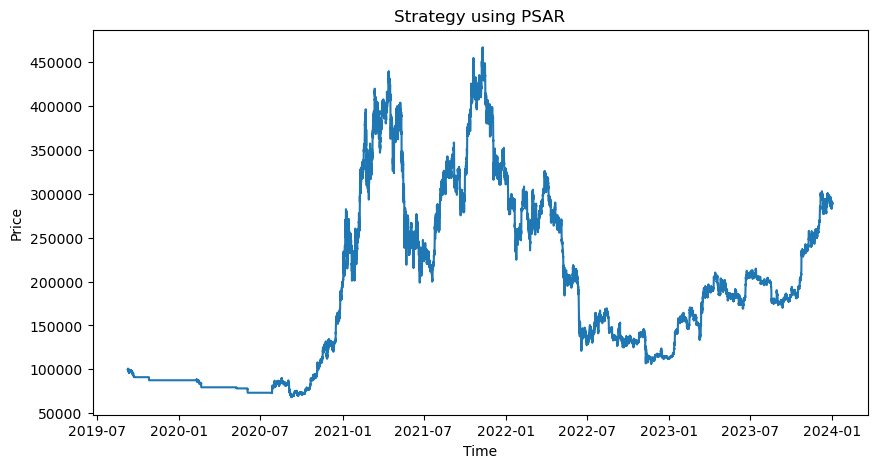

In [202]:
date = pd.to_datetime(data['datetime'])
initial  = 100000
psar = trade(signals_psar,data,initial)
print(psar)
plt.figure(figsize=(10,5))
plt.plot(date,psar)
plt.title('Strategy using PSAR' )
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()


37807    519698.127636
dtype: float64


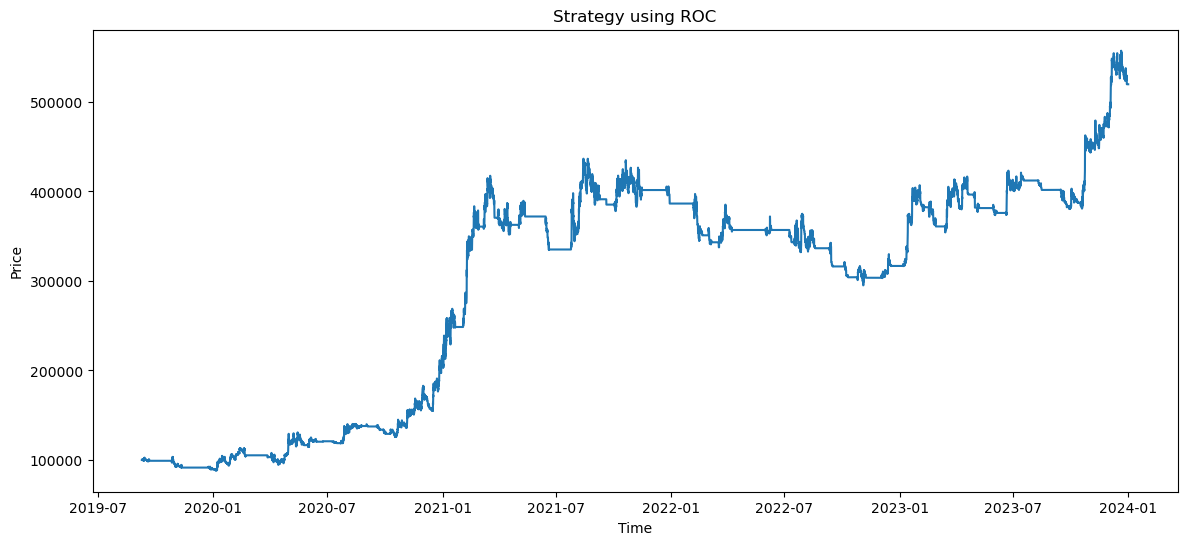

In [210]:
initialf = 100000
trade(signals_roc,data,initialf)
roc =  trade(signals_roc,data,initialf)
print(roc.tail(1))
plt.figure(figsize=(14,6))
plt.plot( date,roc)
plt.title('Strategy using ROC' )
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()


0        100000.000000
1        100000.000000
2        103401.200000
3        103401.200000
4        103401.200000
             ...      
37803    292833.687657
37804    292833.687657
37805    292833.687657
37806    292833.687657
37807    292833.687657
Length: 37808, dtype: float64


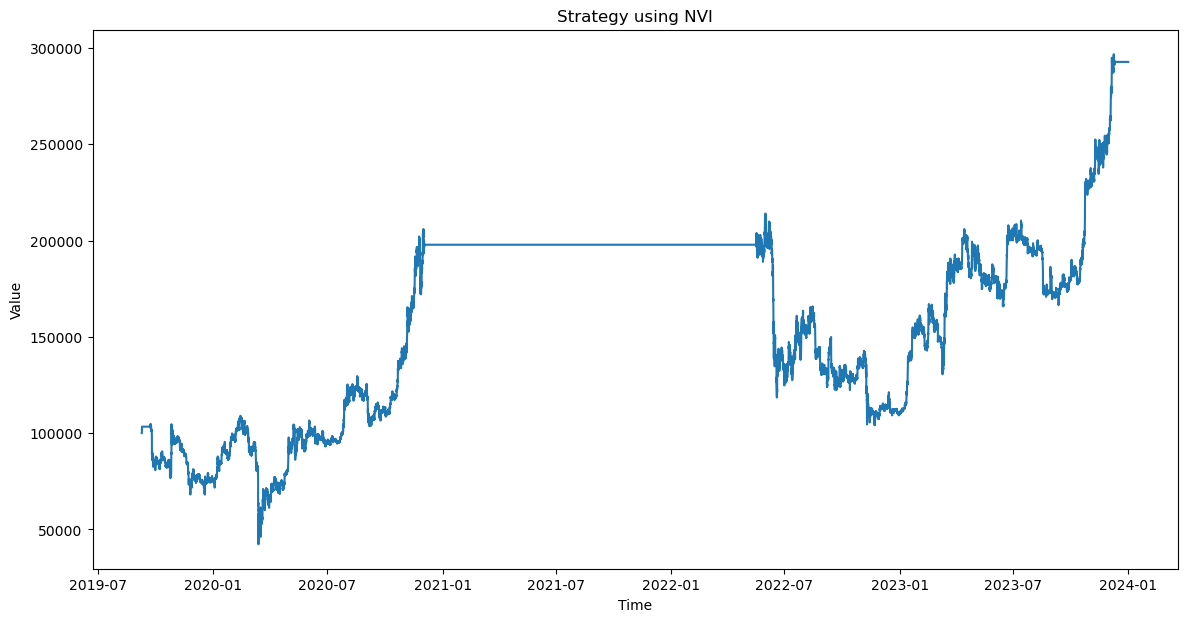

In [124]:
initialff=100000
trade(signals_nvi,data,initialff)
nvi =  trade(signals_nvi,data,initialff)
print(nvi)
plt.figure(figsize=(14,7))
plt.plot(date,nvi)
plt.title('Strategy using NVI' )
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()
